## SphereDetect example

The [FocusScore](https://cellprofiler-manual.s3.amazonaws.com/CellProfiler-4.0.5/modules/measurement.html#:~:text=Measurements%20made%20by%20this%20module,-Blur%20metrics&text=FocusScore%3A%20A%20measure%20of%20the,scores%20correspond%20to%20lower%20bluriness) or [Normalized Variance](https://analyticalsciencejournals.onlinelibrary.wiley.com/doi/epdf/10.1002/jemt.20118) can measure how in focus an image is.

We can make use of this to find the starting point of a spheroid. 

As making an image stack, the spheroid will suddenly be in focus, or the change in FocusScore is large. 

We take the maximum change in focus as the starting point of each spheroid. 






In [1]:
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import os

import tifffile as tiff

In [2]:
def calculate_normalized_variance(data):
    return np.var(data) / np.mean(data)

def read_image(image):
    return tiff.TiffFile(image).asarray()

def assign_plane(group):
    idxmax = group['d_normalized_variance'].idxmax()
    offset = group.index.get_loc(idxmax)
    
    planes = (np.arange(len(group)) - offset)
    planes = np.where(planes < 0, pd.NA, planes)# Replace negative plane values (i.e. rows before max) with NaN
    
    group['Metadata_Plane'] = pd.Series(planes, index=group.index, dtype='Int64')
    return group

In [3]:
# cellprofiler_output = '/share/data/cellprofiler/automation/results/AssayPlate_Corning_3830/5514/8903/featICF_Image.parquet' # Load the image URLS from here
cellprofiler_output = '/share/data/cellprofiler/automation/results/AssayPlate_Corning_3830/5514/8905/icf_images_AssayPlate_Corning_3830.parquet' # Load the image URLS from here
channel = 'URL_SYTO' # One channel might be enough

In [4]:
# Import the image URLs
df = pd.read_parquet(cellprofiler_output)
df['URL_SphereDetect'] = df[channel].str.split(':').apply(lambda parts: ':'.join(parts[1:]))
df['Metadata_Z'] = df['FileName_SYTO'].str.extract(r'Z(\d+)C').astype(int) # Extract the Z slice number from the filename, there might be a better way to do this in the CellProfiler pipeline
df['URL_SphereDetect'] = df['URL_SphereDetect'].str.replace('/share/data/external-datasets/', '/mnt/external-images-pvc/') # This is specific to the way the data is stored in our database

In [5]:
# Calculate the normalized variance for each image
df['normalized_variance'] = df['URL_SphereDetect'].apply(lambda image: calculate_normalized_variance(read_image(image))) # Calculate the normalized variance for each image


In [6]:
# Caluclate the differential normalized variance
df = (
    df.sort_values(['Metadata_Well', 'Metadata_Z'])
      .assign(d_normalized_variance=lambda x: 
              x.groupby('Metadata_Well')['normalized_variance'].diff())
)

In [7]:
# Assign the plane number
df = (
    df.sort_values(['Metadata_Well', 'Metadata_Z'])
      .groupby('Metadata_Well', group_keys=False)
      .apply(assign_plane)
)

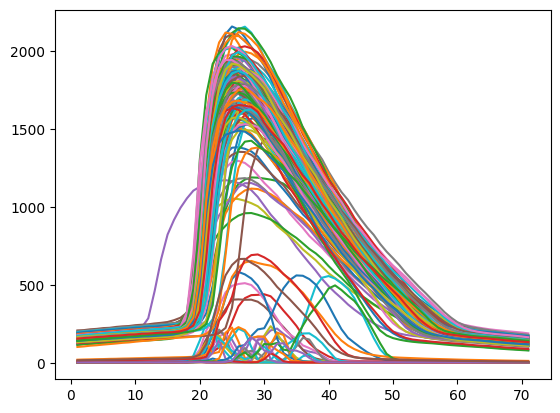

In [8]:
## For inspection only

# Group df by Metadata_Well and sort by Metadata_Z
df = df.sort_values(by='Metadata_Z')
df_grouped = df.groupby('Metadata_Well')

# Then plot the normalized variance across Z for each well
fig, ax = plt.subplots()
for name, group in df_grouped:
    ax.plot(group['Metadata_Z'], group['normalized_variance'], label=name)

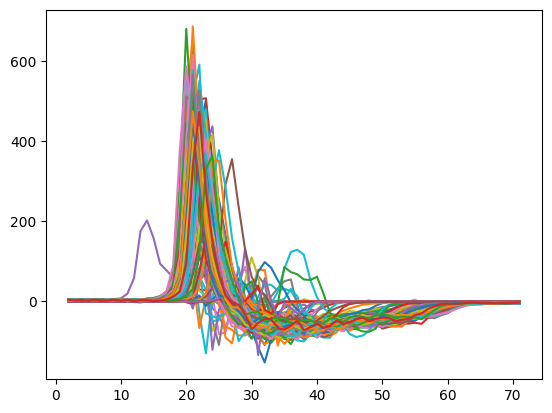

In [9]:
## For inspection only

# Group df by Metadata_Well and sort by Metadata_Z
df = df.sort_values(by='Metadata_Z')
df_grouped = df.groupby('Metadata_Well')

# Then plot the normalized variance across Z for each well
fig, ax = plt.subplots()
for name, group in df_grouped:
    ax.plot(group['Metadata_Z'], group['d_normalized_variance'], label=name)

### Inspect the first slices from our method. 

In [ ]:
# Select the images
selected = dataset.query('name == @name & cmpd_conc == @conc & cell_line == @cell_line')


for i, row in selected.iterrows():
    # Variables
    directory = row.image_url + row.plate_acq_name # Replace with your directory path
    well = row.well_id     # Replace with your actual value

    # Construct the regex pattern 
    pattern = rf"Well-{well}-z{slice_num}-(?P<channel>{channel_pattern}).*\.ome\.tiff$"
    regex = re.compile(pattern)

    # List comprehension to find paths
    image_paths = [
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if regex.search(f)
    ]

    # Initialize the images dictionary
    images = {}

    # Iterate over files in the directory
    for f in os.listdir(directory):
        match = regex.search(f)

        if match:
            channel_name = match.group('channel')
            if channel_name in [c for c in channels]:
                image_path = os.path.join(directory, f)
                images[channel_name] = Image.open(image_path)


    # Proceed if all channels are present
    if all(ch in images for ch in channels):
        composite_image = create_composite_image(images, channel_min_max, channel_to_color)
        print(row.plate_well)
        composite_image.show()
    else:
        print(f"Not all channels are present for Well {row.plate_well}.")

    
    
    # # Print the resulting list of image paths
    # print(image_paths)

### Select the images to render: First slices
# These spheroids: 
barcode = 'PB000140'
wells = ['H11', 'H12', 'G11', 'G12']

# Slice to analys 
slice_num = '0'    # Replace with your actual value

# These channels 
channels = ['HOECHST', 'PHAandWGA', 'SYTO']
# Ensure channels are strings and create a regex pattern 
channels = [str(ch) for ch in channels]
channel_pattern = '|'.join(channels)

channel_min_max = {
    'HOECHST': (554, 1350),
    'SYTO': (2036, 5300),
    'PHAandWGA': (2616, 6300)
}

channel_to_color = {
    'HOECHST': 'blue',
    'SYTO': 'green',
    'PHAandWGA': 'red'
}
# Select the images
selected = dataset.query('plate_barcode == @barcode & well_id in @wells')


for i, row in selected.iterrows():
    # Variables
    directory = row.image_url + row.plate_acq_name # Replace with your directory path
    well = row.well_id     # Replace with your actual value

    # Construct the regex pattern 
    pattern = rf"Well-{well}-z{slice_num}-(?P<channel>{channel_pattern}).*\.ome\.tiff$"
    regex = re.compile(pattern)

    # List comprehension to find paths
    image_paths = [
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if regex.search(f)
    ]

    # Initialize the images dictionary
    images = {}

    # Iterate over files in the directory
    for f in os.listdir(directory):
        match = regex.search(f)

        if match:
            channel_name = match.group('channel')
            if channel_name in [c for c in channels]:
                image_path = os.path.join(directory, f)
                images[channel_name] = Image.open(image_path)


    # Proceed if all channels are present
    if all(ch in images for ch in channels):
        composite_image = create_composite_image(images, channel_min_max, channel_to_color)
        print(row.plate_well)
        composite_image.show()
    else:
        print(f"Not all channels are present for Well {row.plate_well}.")

    
    
    # # Print the resulting list of image paths
    # print(image_paths)

### Select the images to render: Single Channels